In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


In [2]:
known_at_application = ['credit.policy', 'purpose', 'int.rate', 'installment',
                         'log.annual.inc', 'dti', 'fico', 'days.with.cr.line',
                         'revol.bal', 'revol.util', 'inq.last.6mths',
                         'delinq.2yrs', 'pub.rec']
target = ['default']
computed_after_outcome = ['tot.payment', 'principal', 'interest']

field_roles = pd.DataFrame({
    'field': known_at_application + target + computed_after_outcome,
    'role': (['Known at application'] * len(known_at_application)
             + ['Target (outcome)']
             + ['Computed after outcome (KPI, not a predictor)'] * len(computed_after_outcome))
})
display(field_roles)


,field,role
0,credit.policy,Known at application
1,purpose,Known at application
2,int.rate,Known at application
3,installment,Known at application
4,log.annual.inc,Known at application
5,dti,Known at application
6,fico,Known at application
7,days.with.cr.line,Known at application
8,revol.bal,Known at application
9,revol.util,Known at application


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  default            9578 non-null   int64  
 14  tot.payment        9578 non-null   float64
 15  principal          9578 non-null   float64
 16  interest           9578 non-null   

In [4]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


In [5]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
missing['% Missing'] = (missing['Missing Values'] / len(df) * 100).round(2)
display(missing)
print(f"\nOverall default rate: {df['default'].mean()*100:.1f}%")

,Missing Values,% Missing
credit.policy,0,0.0
purpose,0,0.0
int.rate,0,0.0
installment,0,0.0
log.annual.inc,0,0.0
dti,0,0.0
fico,0,0.0
days.with.cr.line,0,0.0
revol.bal,0,0.0
revol.util,0,0.0



Overall default rate: 16.0%


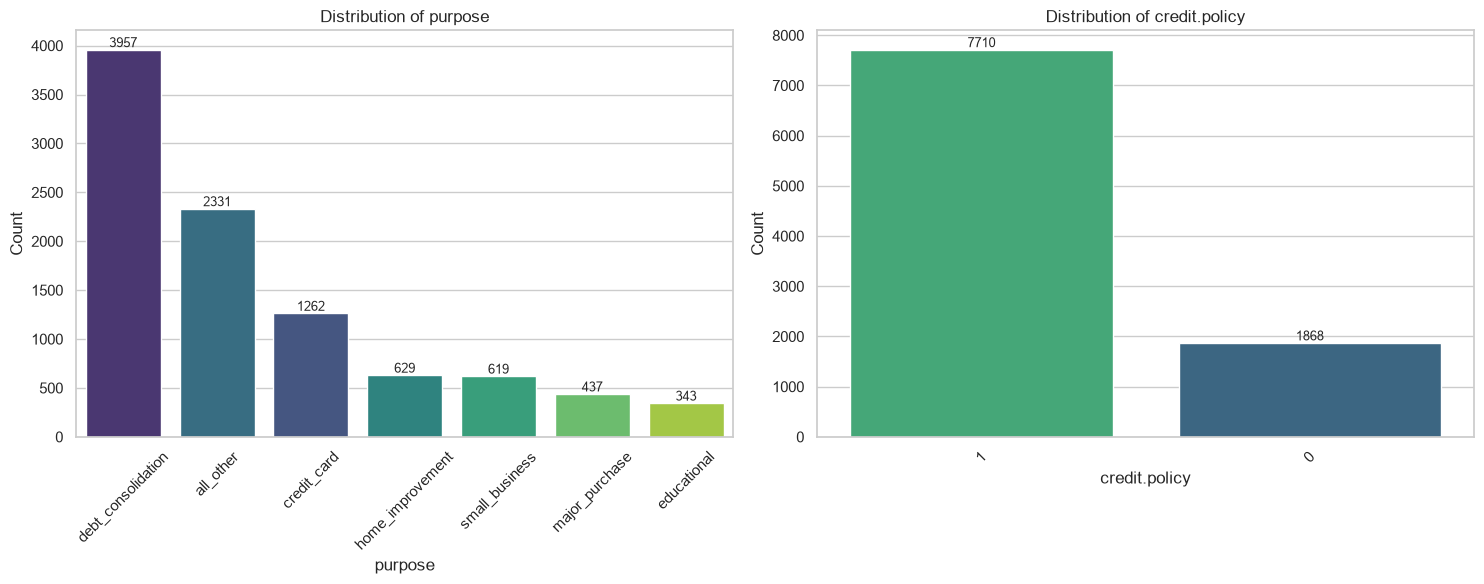

In [6]:
categorical_cols = ['purpose', 'credit.policy']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 6))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

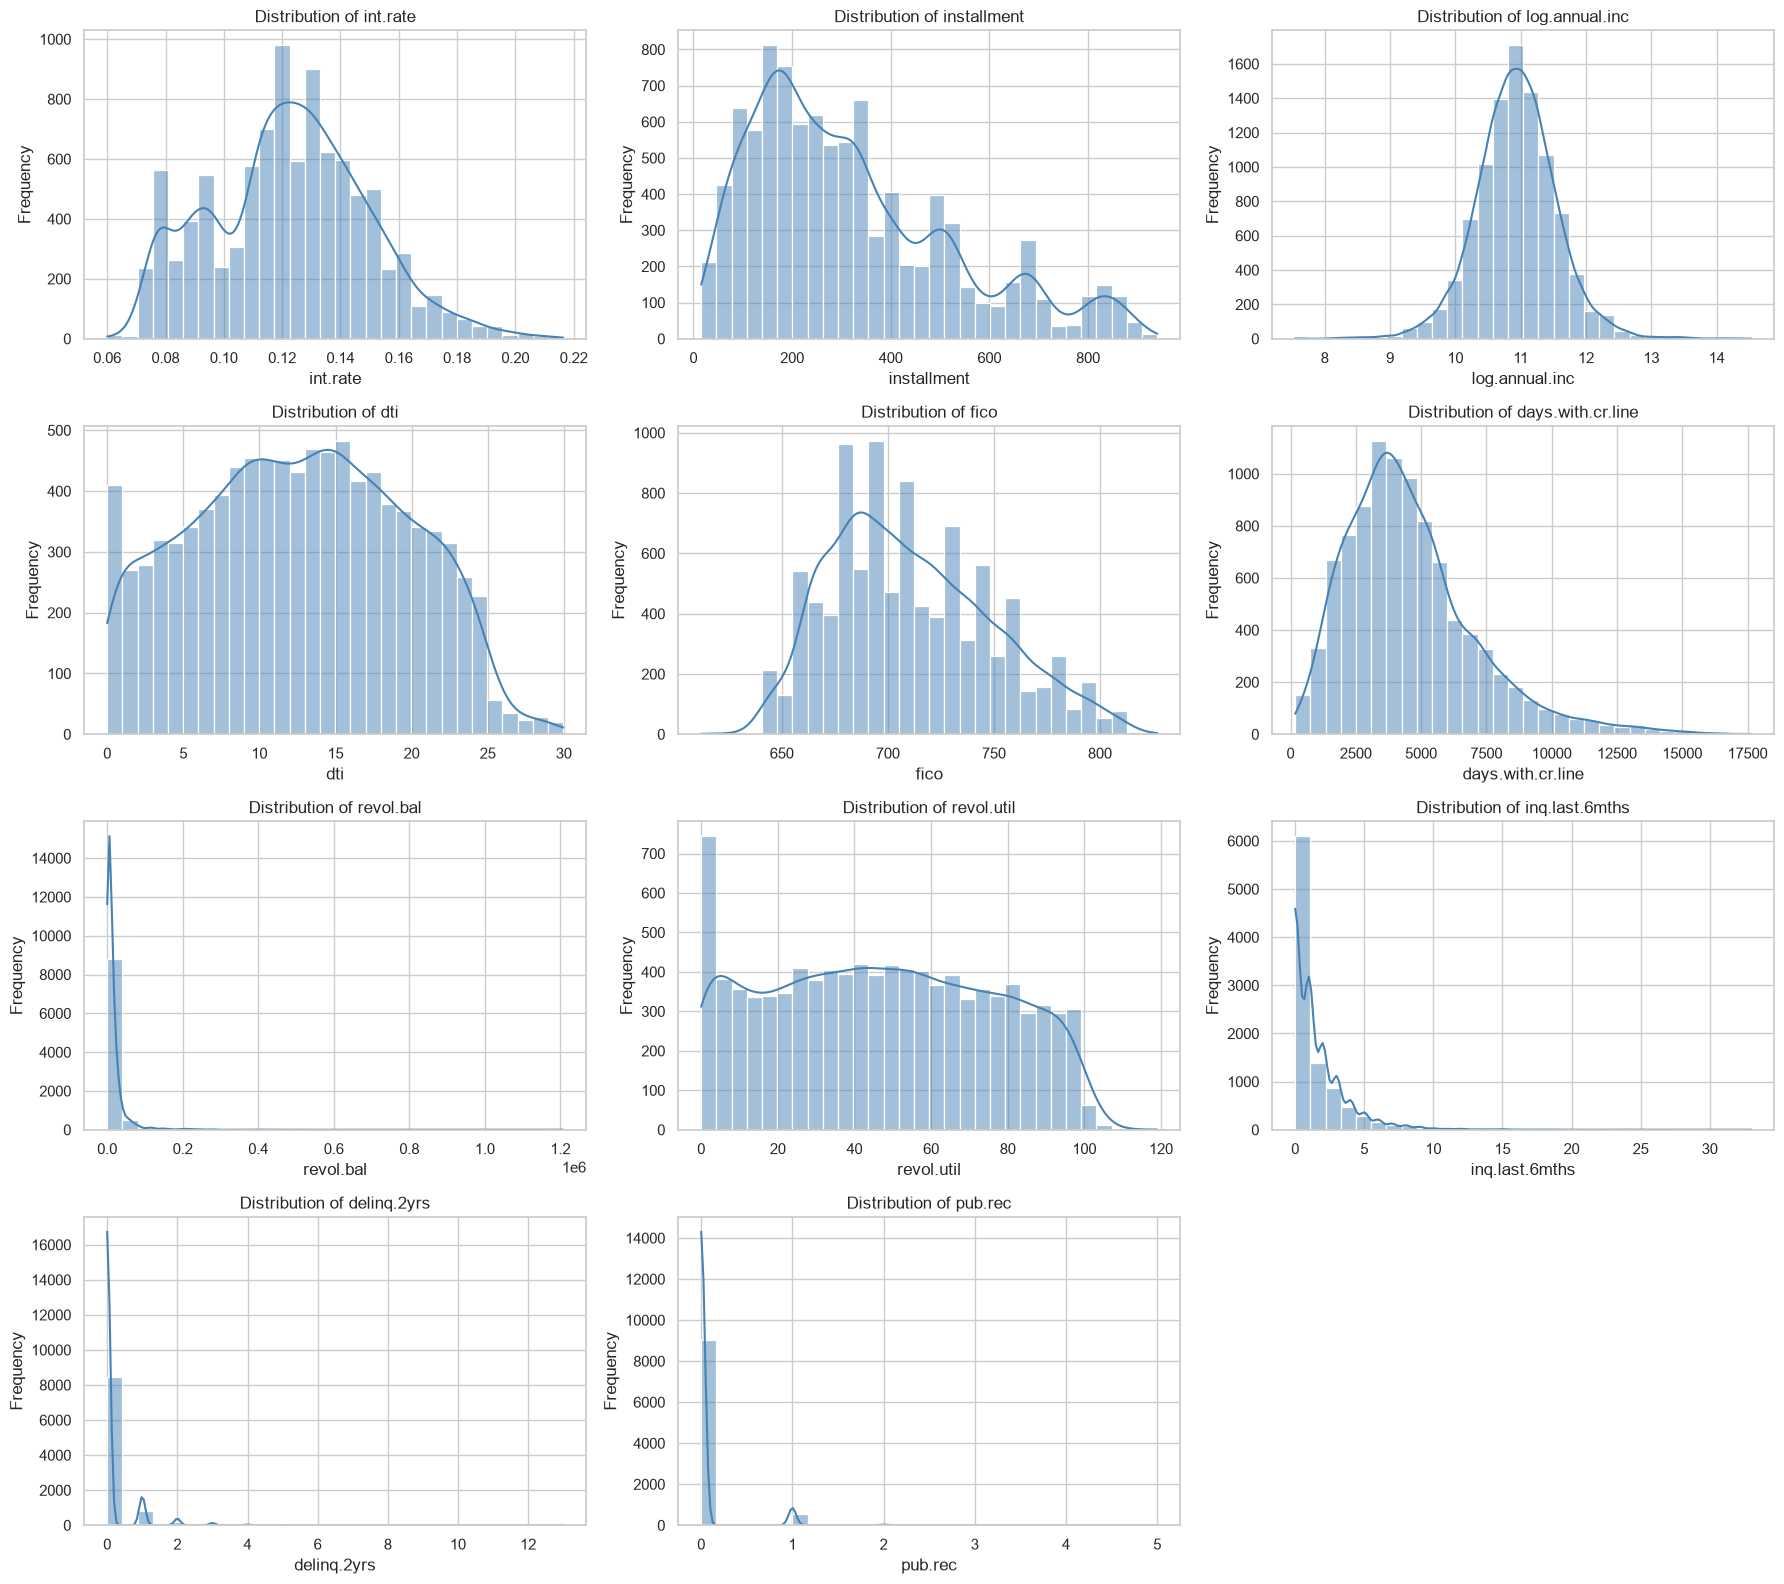

In [7]:
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
                'delinq.2yrs', 'pub.rec']

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../output/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

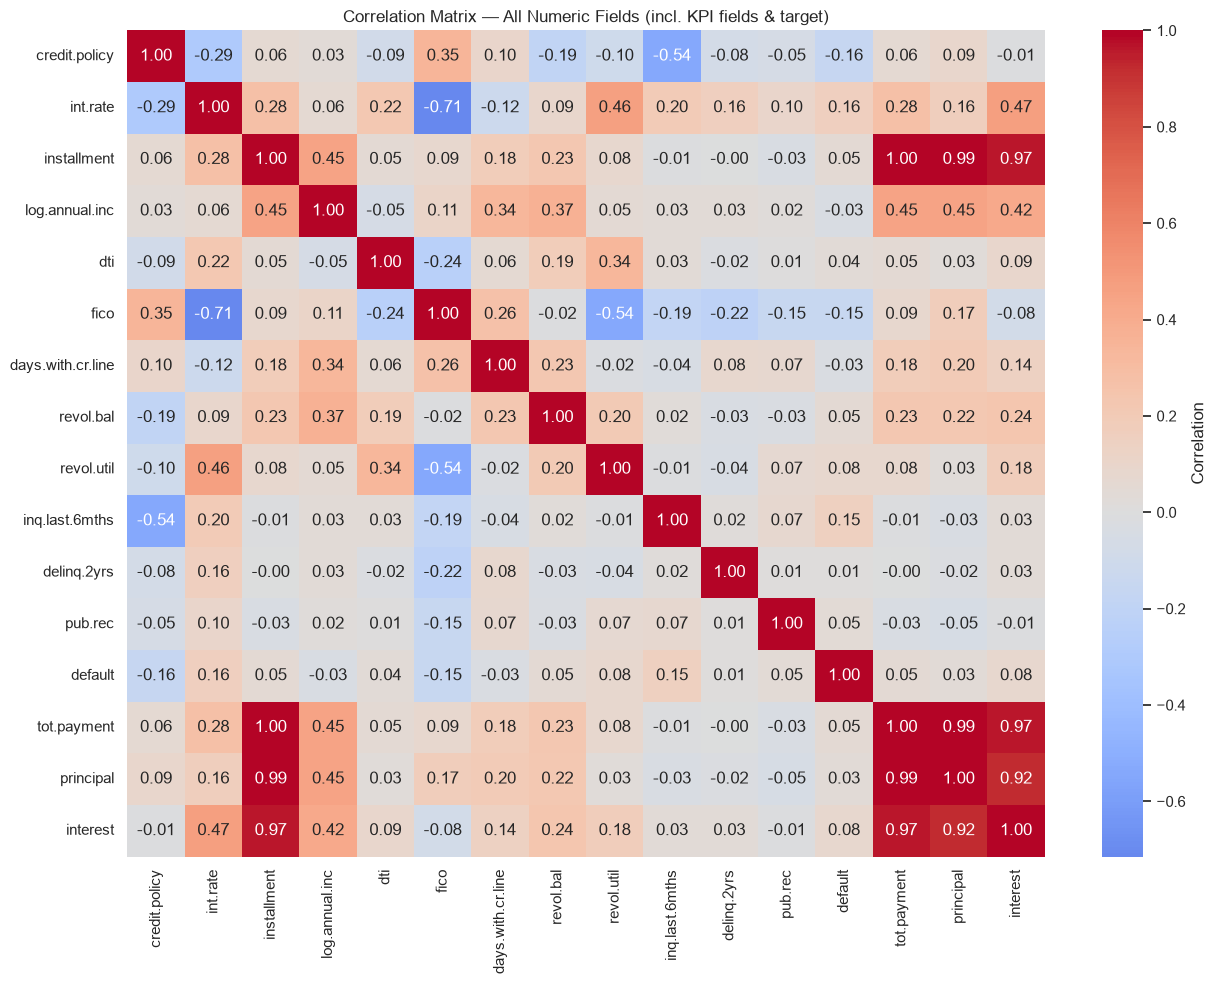

In [8]:
full_numeric = df.select_dtypes(include=[np.number])
corr_full = full_numeric.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields (incl. KPI fields & target)')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()


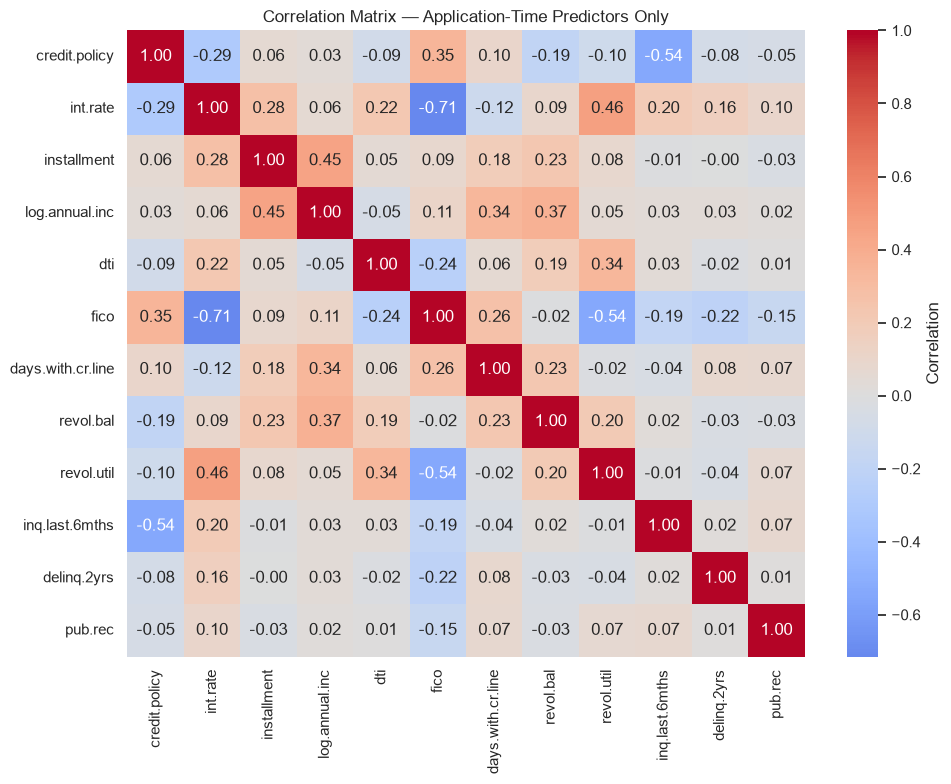

In [9]:
predictor_cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
                   'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
                   'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

corr_predictors = df[predictor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_predictors, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Application-Time Predictors Only')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

Defaulters: 1,533 loans   |   Non-defaulters: 8,045 loans


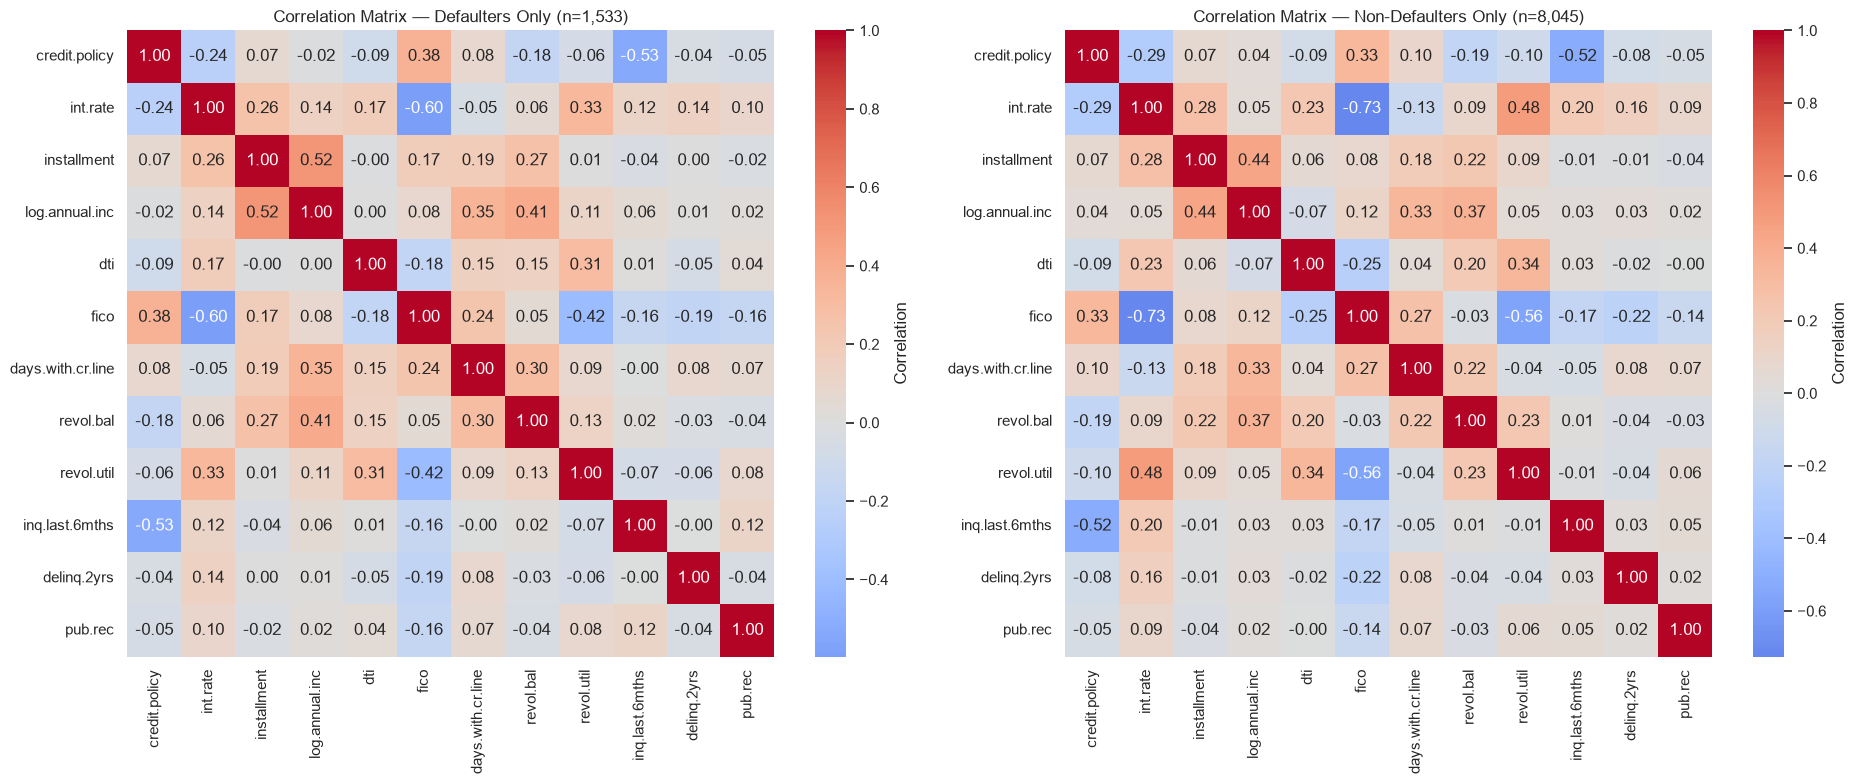

Largest shifts in correlation between defaulters and non-defaulters:
  int.rate             vs revol.util            defaulters=+0.330  non-defaulters=+0.483  shift=-0.153
  fico                 vs revol.util            defaulters=-0.416  non-defaulters=-0.558  shift=+0.142
  int.rate             vs fico                  defaulters=-0.597  non-defaulters=-0.726  shift=+0.129
  days.with.cr.line    vs revol.util            defaulters=+0.087  non-defaulters=-0.042  shift=+0.129
  dti                  vs days.with.cr.line     defaulters=+0.155  non-defaulters=+0.044  shift=+0.111
  revol.bal            vs revol.util            defaulters=+0.131  non-defaulters=+0.229  shift=-0.098
  int.rate             vs log.annual.inc        defaulters=+0.144  non-defaulters=+0.046  shift=+0.098
  installment          vs fico                  defaulters=+0.174  non-defaulters=+0.080  shift=+0.094


In [10]:
defaulters = df[df['default'] == 1]
nondefaulters = df[df['default'] == 0]
print(f"Defaulters: {len(defaulters):,} loans   |   Non-defaulters: {len(nondefaulters):,} loans")

corr_default = defaulters[predictor_cols].corr()
corr_nondefault = nondefaulters[predictor_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
sns.heatmap(corr_default, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'}, ax=axes[0])
axes[0].set_title(f'Correlation Matrix — Defaulters Only (n={len(defaulters):,})')
sns.heatmap(corr_nondefault, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'}, ax=axes[1])
axes[1].set_title(f'Correlation Matrix — Non-Defaulters Only (n={len(nondefaulters):,})')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

# Where does the covariance structure shift the most between the two groups?
diff = (corr_default - corr_nondefault)
pairs = []
cols = predictor_cols
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], diff.iloc[i, j], corr_default.iloc[i, j], corr_nondefault.iloc[i, j]))
pairs.sort(key=lambda p: -abs(p[2]))

print("Largest shifts in correlation between defaulters and non-defaulters:")
for a, b, d, cd, cn in pairs[:8]:
    print(f"  {a:20s} vs {b:20s}  defaulters={cd:+.3f}  non-defaulters={cn:+.3f}  shift={d:+.3f}")


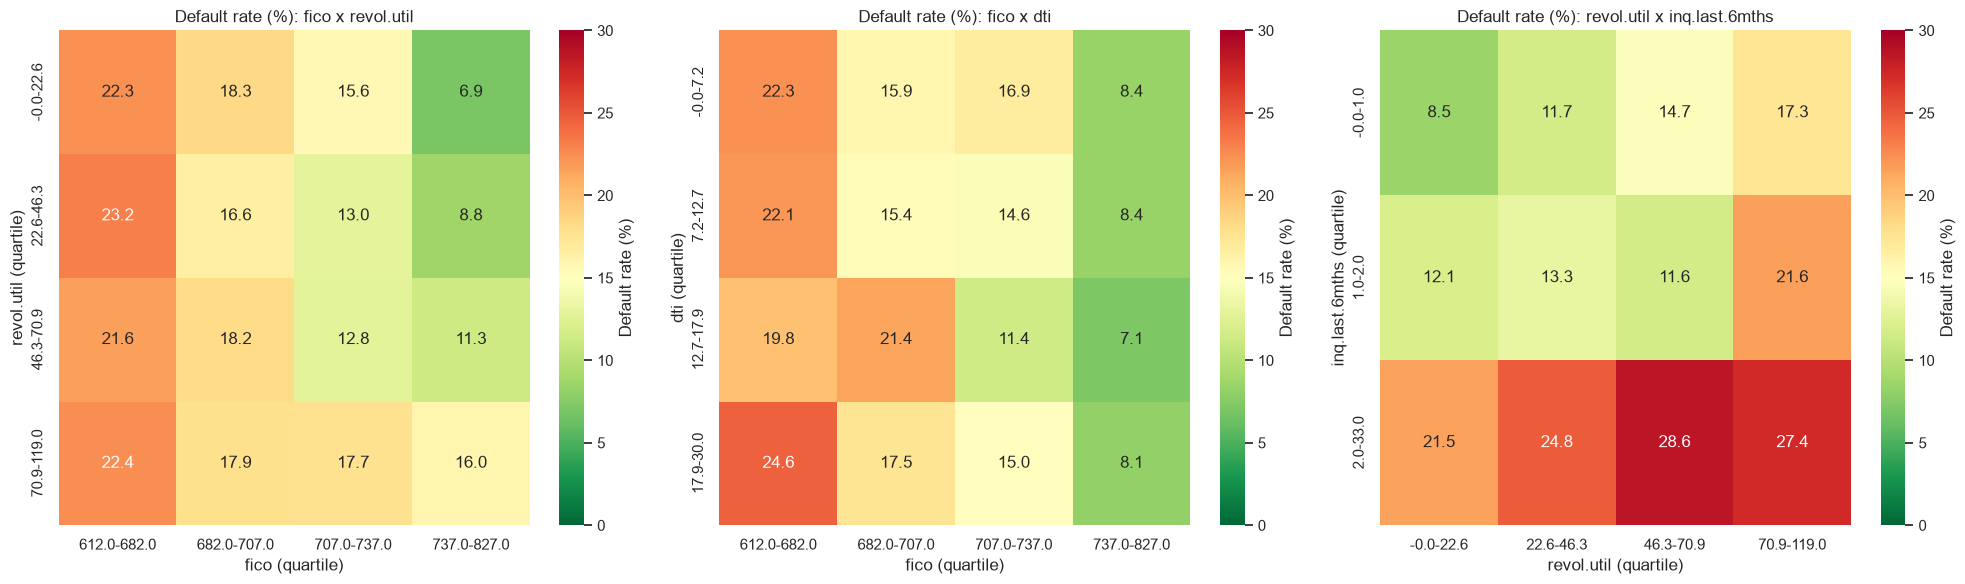

fico x revol.util: min cell = 6.9%, max cell = 23.2%, spread = 16.3pp
fico x dti: min cell = 7.1%, max cell = 24.6%, spread = 17.5pp
revol.util x inq.last.6mths: min cell = 8.5%, max cell = 28.6%, spread = 20.1pp


In [11]:
def bivariate_default_rate(ax, df, xcol, ycol, bins=4):
    x_bin = pd.qcut(df[xcol], bins, duplicates='drop')
    y_bin = pd.qcut(df[ycol], bins, duplicates='drop')
    tab = df.groupby([y_bin, x_bin], observed=True)['default'].agg(['mean', 'count'])
    rate = (tab['mean'] * 100).unstack()
    n = tab['count'].unstack()
    sns.heatmap(rate, annot=True, fmt='.1f', cmap='RdYlGn_r', vmin=0, vmax=30,
                cbar_kws={'label': 'Default rate (%)'}, ax=ax,
                xticklabels=[f'{iv.left:.1f}-{iv.right:.1f}' for iv in rate.columns],
                yticklabels=[f'{iv.left:.1f}-{iv.right:.1f}' for iv in rate.index])
    ax.set_xlabel(f'{xcol} (quartile)')
    ax.set_ylabel(f'{ycol} (quartile)')
    ax.set_title(f'Default rate (%): {xcol} x {ycol}')
    return rate, n

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
rate1, n1 = bivariate_default_rate(axes[0], df, 'fico', 'revol.util')
rate2, n2 = bivariate_default_rate(axes[1], df, 'fico', 'dti')
rate3, n3 = bivariate_default_rate(axes[2], df, 'revol.util', 'inq.last.6mths')
plt.tight_layout()
plt.savefig('../output/bivariate_default_rate_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

for name, rate in [('fico x revol.util', rate1), ('fico x dti', rate2), ('revol.util x inq.last.6mths', rate3)]:
    print(f"{name}: min cell = {rate.min().min():.1f}%, max cell = {rate.max().max():.1f}%, "
          f"spread = {rate.max().max() - rate.min().min():.1f}pp")

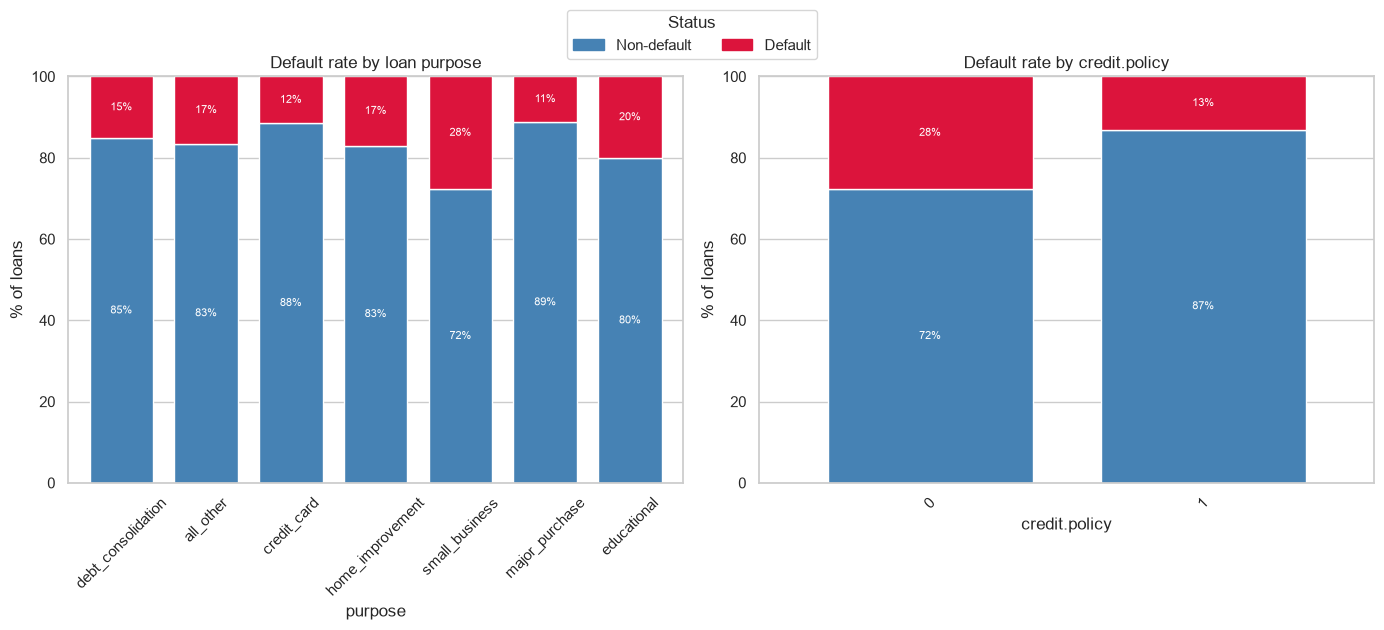

In [12]:
default_palette = {0: 'steelblue', 1: 'crimson'}
default_labels = {0: 'Non-default', 1: 'Default'}

def plot_100pct_stacked(ax, series, default, title, xlabel, order=None):
    tab = pd.crosstab(series, default, normalize='index') * 100
    if order is not None:
        tab = tab.reindex(order)
    tab = tab.rename(columns=default_labels)
    tab[[default_labels[0], default_labels[1]]].plot(
        kind='bar', stacked=True, ax=ax,
        color=[default_palette[0], default_palette[1]], width=0.75, legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% of loans')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        labels = [f'{v:.0f}%' if v >= 5 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = df['purpose'].value_counts().index
plot_100pct_stacked(axes[0], df['purpose'], df['default'], 'Default rate by loan purpose', 'purpose', order=order)
plot_100pct_stacked(axes[1], df['credit.policy'], df['default'], 'Default rate by credit.policy', 'credit.policy')
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.06), ncol=2)
plt.tight_layout()
plt.savefig('../output/categorical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


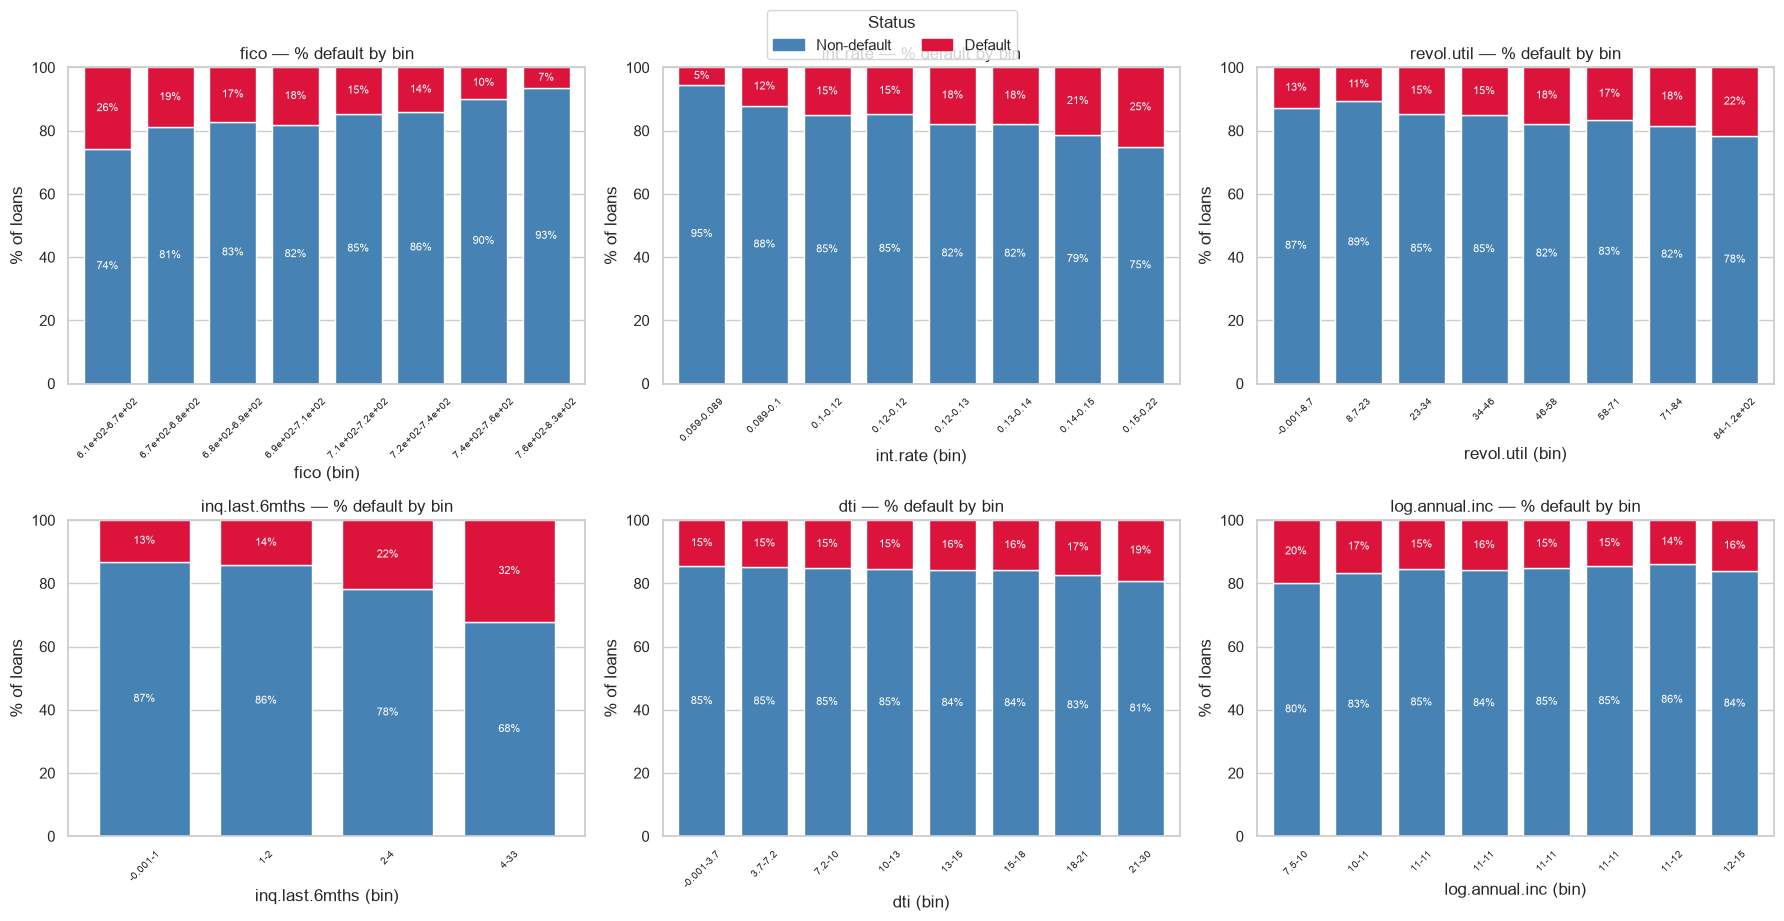

In [13]:
default_drivers = ['fico', 'int.rate', 'revol.util', 'inq.last.6mths', 'dti', 'log.annual.inc']
n_bins = 8
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(default_drivers):
    binned = pd.qcut(df[col], q=n_bins, duplicates='drop')
    bin_order = binned.cat.categories
    plot_100pct_stacked(axes[i], binned, df['default'], f'{col} — % default by bin', f'{col} (bin)', order=bin_order)
    axes[i].set_xticklabels([f'{iv.left:.2g}-{iv.right:.2g}' for iv in bin_order], fontsize=7)
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.03), ncol=2)
plt.tight_layout()
plt.savefig('../output/numerical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
cluster_vars = ['installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])
print(f"Clustering on {X_scaled.shape[0]} loans x {X_scaled.shape[1]} scaled features")


Clustering on 9578 loans x 8 scaled features


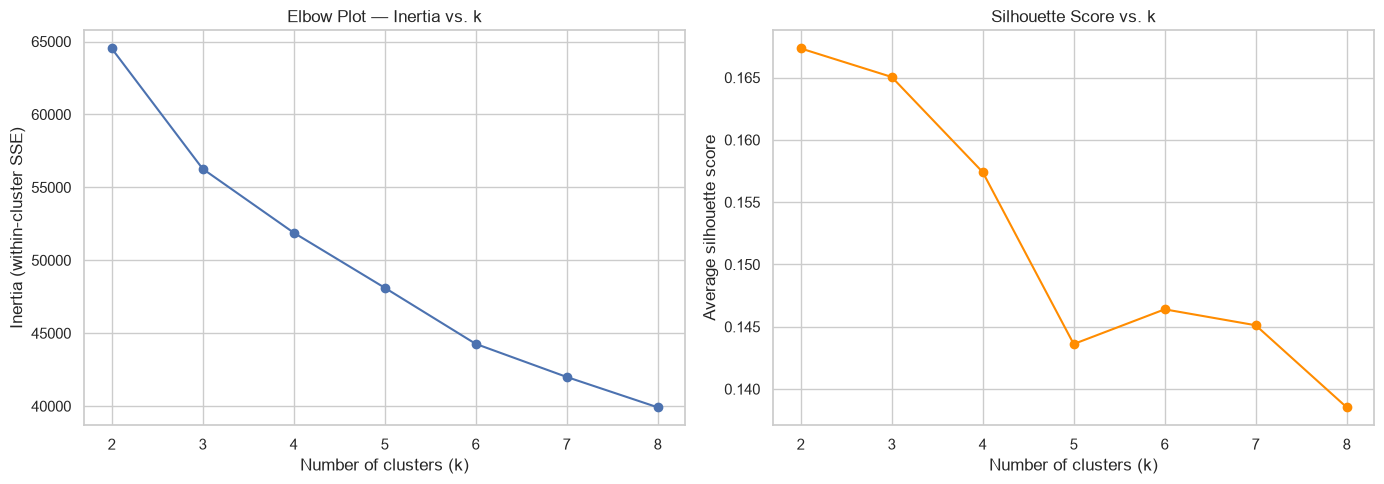

k=2: inertia=64527, silhouette=0.1673
k=3: inertia=56269, silhouette=0.1650
k=4: inertia=51891, silhouette=0.1574
k=5: inertia=48116, silhouette=0.1436
k=6: inertia=44268, silhouette=0.1464
k=7: inertia=41999, silhouette=0.1451
k=8: inertia=39917, silhouette=0.1385


In [15]:
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Plot — Inertia vs. k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].grid(True)

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Average silhouette score')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('../output/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.0f}, silhouette={sil:.4f}")


In [16]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_sizes_pct = (cluster_sizes / len(df) * 100).round(1)
print("Cluster sizes:")
display(pd.DataFrame({'n_loans': cluster_sizes, '% of loans': cluster_sizes_pct}))

cluster_profile = df.groupby('cluster')[cluster_vars].mean().round(2)
cluster_profile['default_rate_%'] = (df.groupby('cluster')['default'].mean() * 100).round(1)
cluster_profile['credit_policy_pass_%'] = (df.groupby('cluster')['credit.policy'].mean() * 100).round(1)
cluster_profile['int.rate_%'] = (df.groupby('cluster')['int.rate'].mean() * 100).round(2)  # NOT a clustering input — shown only as external validation
display(cluster_profile)


Cluster sizes:


,n_loans,% of loans
cluster,,
0,188,2.0
1,3785,39.5
2,2768,28.9
3,2837,29.6


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,default_rate_%,credit_policy_pass_%,int.rate_%
cluster,,,,,,,,,,,
0,504.70,12.00,16.68,716.04,7097.26,190815.01,56.76,2.04,28.2,19.7,13.01
1,201.65,10.54,13.52,689.08,3110.50,8022.35,52.69,1.93,18.9,70.9,12.95
2,474.18,11.29,15.49,698.88,5611.15,26038.96,66.79,1.47,18.3,83.0,13.54
3,312.15,11.03,8.31,751.22,5302.73,8349.77,18.77,1.18,9.2,94.9,10.05


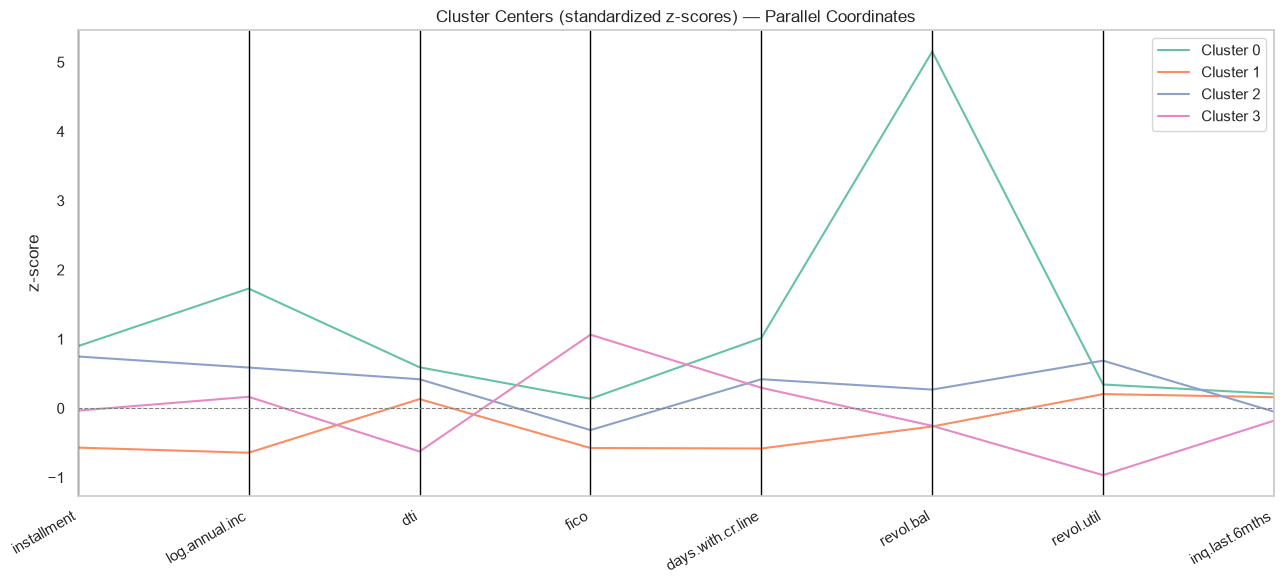

In [17]:
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_vars)
centers_df['cluster'] = [f'Cluster {i}' for i in range(len(centers_df))]

plt.figure(figsize=(13, 6))
parallel_coordinates(centers_df, 'cluster', color=sns.color_palette('Set2', 4))
plt.title('Cluster Centers (standardized z-scores) — Parallel Coordinates')
plt.ylabel('z-score')
plt.xticks(rotation=30, ha='right')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../output/kmeans_parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

print('Explained variance ratio per component:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'PC{i+1}: {ratio*100:.2f}%')
print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_explained_variance):
    print(f'PC{i+1}: {cum*100:.2f}%')

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['default'] = df['default'].values
pca_df['cluster'] = df['cluster'].values
display(pca_df.head())


Explained variance ratio per component:
PC1: 24.77%
PC2: 23.12%
PC3: 12.98%
PC4: 11.18%
PC5: 9.04%
PC6: 8.58%
PC7: 5.73%
PC8: 4.59%

Cumulative explained variance:
PC1: 24.77%
PC2: 47.90%
PC3: 60.88%
PC4: 72.06%
PC5: 81.10%
PC6: 89.68%
PC7: 95.41%
PC8: 100.00%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,default,cluster
0,2.146251,0.210332,-0.700960,-0.672079,1.756365,0.179680,-0.383750,0.051456,0,2
1,0.059457,-0.870066,-0.762315,-0.517036,-0.561036,0.495818,0.354790,0.606763,0,1
2,-0.764727,0.041934,-0.099588,-0.110597,0.344577,-0.185407,-0.516415,-1.100793,0,1
3,-0.000933,-0.369294,-0.039891,-0.704260,-1.232486,0.354183,0.491119,0.802900,0,1
4,-0.509496,-0.571864,-0.474836,-0.120891,-0.552862,-0.248133,1.310729,-0.856565,0,1


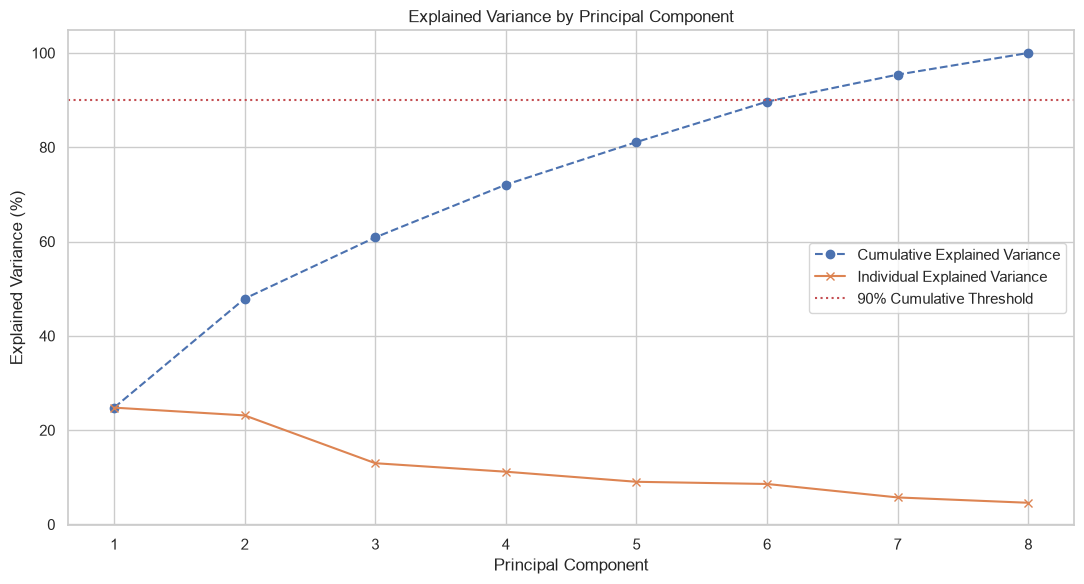

In [19]:
num_components = range(1, len(cumulative_explained_variance) + 1)

plt.figure(figsize=(11, 6))
plt.plot(num_components, cumulative_explained_variance * 100, marker='o', linestyle='--',
         label='Cumulative Explained Variance')
plt.plot(num_components, explained_variance_ratio * 100, marker='x', linestyle='-',
         label='Individual Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Component')
plt.grid(True)
plt.xticks(num_components)
plt.axhline(y=90, color='r', linestyle=':', label='90% Cumulative Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('../output/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()


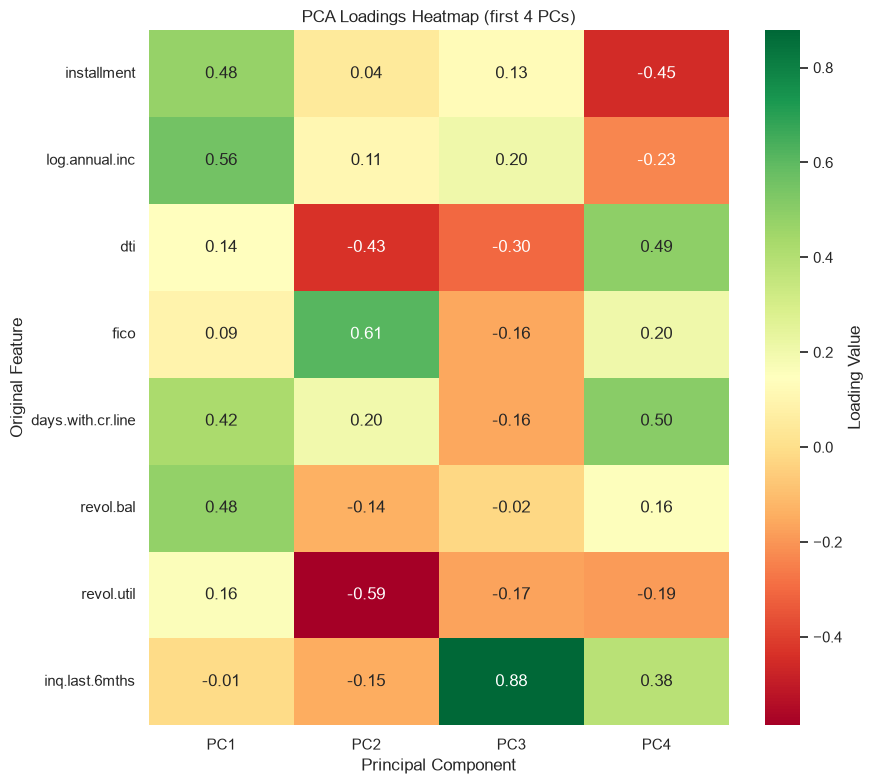

Top |loadings| for PC1:
  log.annual.inc: +0.556
  revol.bal: +0.482
  installment: +0.476
  days.with.cr.line: +0.422

Top |loadings| for PC2:
  fico: +0.612
  revol.util: -0.586
  dti: -0.432
  days.with.cr.line: +0.199

Top |loadings| for PC3:
  inq.last.6mths: +0.878
  dti: -0.301
  log.annual.inc: +0.204
  revol.util: -0.170



In [20]:
loadings_df = pd.DataFrame(pca.components_, columns=cluster_vars,
                            index=[f'PC{i+1}' for i in range(pca.n_components_)])

n_show = min(4, loadings_df.shape[0])
plt.figure(figsize=(9, 8))
sns.heatmap(loadings_df.iloc[:n_show].T, annot=True, cmap='RdYlGn', fmt=".2f",
            cbar_kws={'label': 'Loading Value'})
plt.title(f'PCA Loadings Heatmap (first {n_show} PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()
plt.savefig('../output/pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings_df.loc[pc].abs().sort_values(ascending=False).head(4)
    print(f"Top |loadings| for {pc}:")
    for feat in top.index:
        print(f"  {feat}: {loadings_df.loc[pc, feat]:+.3f}")
    print()


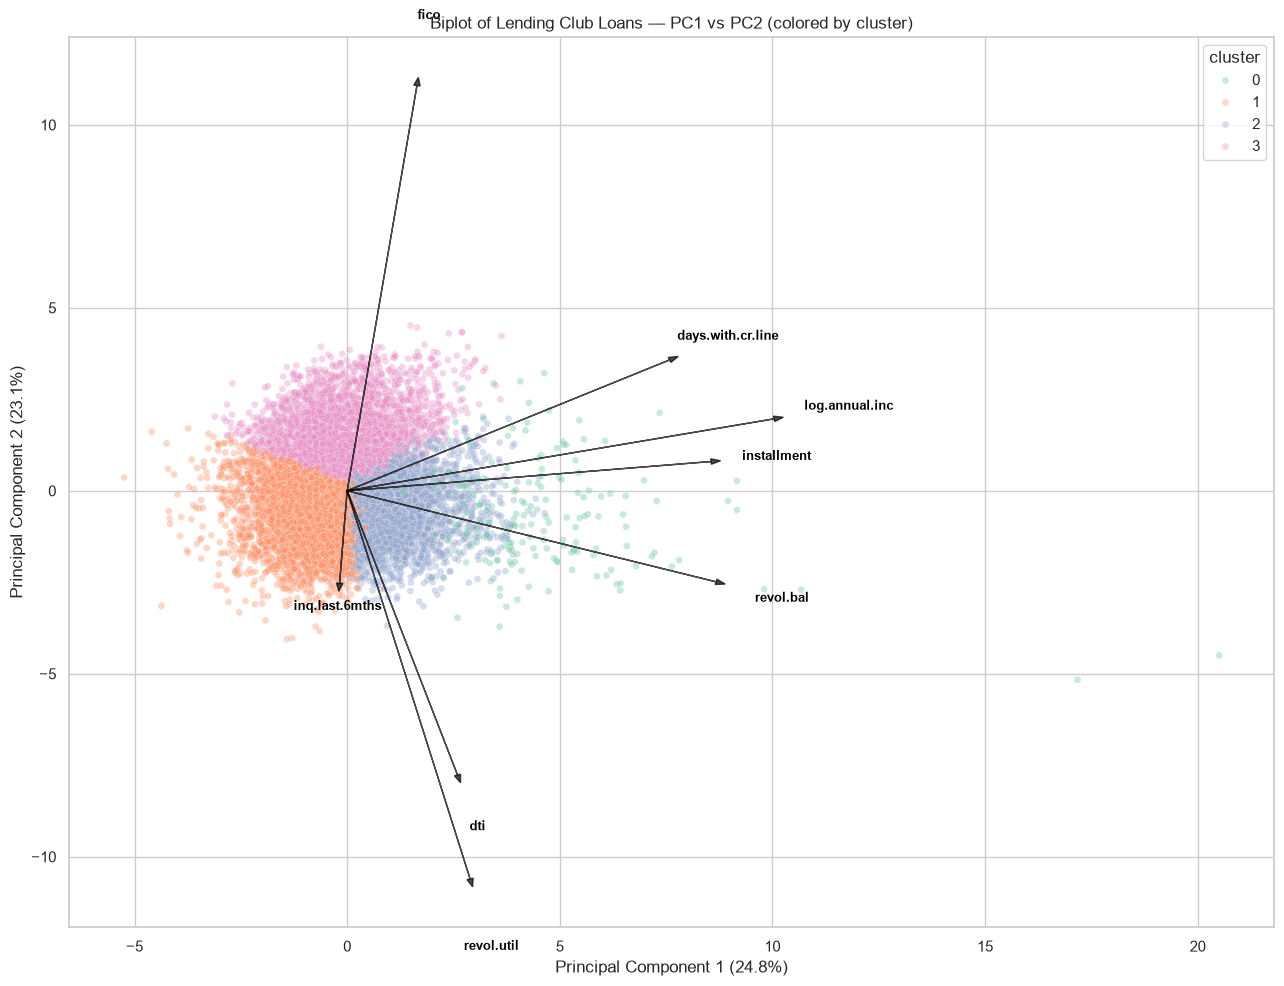

In [21]:
loadings = pca.components_
feature_names = cluster_vars

fig = plt.figure(figsize=(13, 10))
n_clusters = pca_df['cluster'].nunique()
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['cluster'],
                 palette=sns.color_palette('Set2', n_clusters), alpha=0.35, s=25)

scale = np.abs(pca_df[['PC1', 'PC2']]).max().max() * 0.9
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[0, i] * scale, loadings[1, i] * scale,
              color='black', alpha=0.7, head_width=0.15, length_includes_head=True)
    plt.text(loadings[0, i] * scale * 1.15, loadings[1, i] * scale * 1.15, feature,
              color='black', ha='center', va='center', fontsize=9, fontweight='bold')

plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('Biplot of Lending Club Loans — PC1 vs PC2 (colored by cluster)')
plt.legend(title='cluster', loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('../output/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
inspect_cols = cluster_vars + ['purpose', 'credit.policy', 'default', 'int.rate', 'cluster']
# int.rate and cluster are shown for context only — neither was a PCA input

for pc in ['PC1', 'PC2']:
    idx_max, idx_min = pca_df[pc].idxmax(), pca_df[pc].idxmin()
    print(f"=== Extreme HIGH {pc} (loan #{idx_max}, {pc}={pca_df.loc[idx_max, pc]:.2f}) ===")
    display(df.loc[[idx_max], inspect_cols])
    print(f"=== Extreme LOW {pc} (loan #{idx_min}, {pc}={pca_df.loc[idx_min, pc]:.2f}) ===")
    display(df.loc[[idx_min], inspect_cols])


=== Extreme HIGH PC1 (loan #9535, PC1=20.51) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
9535,831.52,12.765688,11.38,717,8520.041667,1207359,56.0,7,small_business,0,1,0.1496,0


=== Extreme LOW PC1 (loan #7897, PC1=-5.24) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
7897,15.91,7.600902,0.0,702,238.958333,0,0.0,6,all_other,0,1,0.0901,1


=== Extreme HIGH PC2 (loan #113, PC2=4.52) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
113,64.96,11.608236,0.22,812,16213.0,50,0.3,0,debt_consolidation,1,0,0.0712,3


=== Extreme LOW PC2 (loan #9042, PC2=-5.17) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
9042,735.06,13.304685,14.39,672,7620.0,952013,99.0,6,small_business,0,0,0.2011,0


## Update 1 plots

These plots recreate the Update 1 charts with default seaborn and matplotlib styling. The comments in each cell describe the plotting prompt and the choices used.

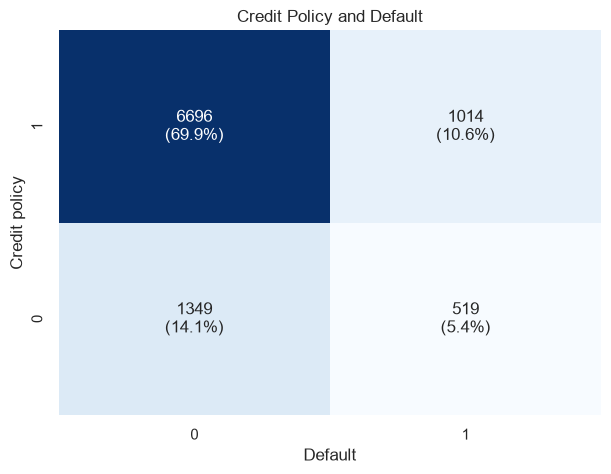

In [27]:
# Prompt: Recreate the policy-versus-default chart as a plain confusion-style
# plot. Show each cell's loan count and the percentage of the full population
# in parentheses, using the normal seaborn heatmap appearance.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/loanskpi.csv")
policy_default_counts = pd.crosstab(
    df["credit.policy"],
    df["default"],
).reindex(index=[1, 0], columns=[0, 1])
policy_default_percentages = policy_default_counts / len(df) * 100
annotations = (
    policy_default_counts.astype(int).astype(str)
    + "\n("
    + policy_default_percentages.round(1).astype(str)
    + "%)"
)

plt.figure(figsize=(7, 5))
sns.heatmap(policy_default_counts, annot=annotations, fmt="", cmap="Blues", cbar=False)
plt.title("Credit Policy and Default")
plt.xlabel("Default")
plt.ylabel("Credit policy")
plt.show()

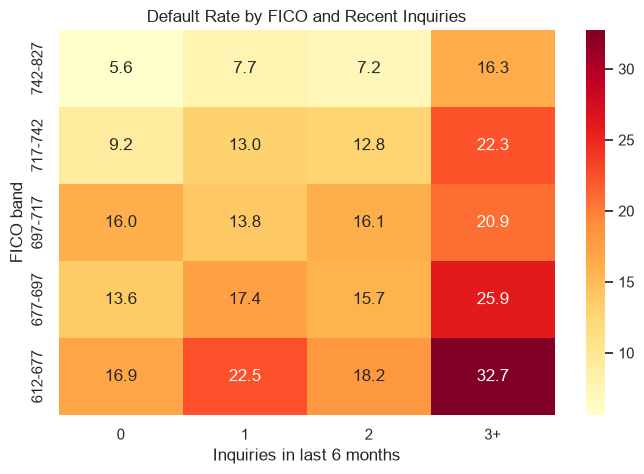

In [24]:
# Prompt: Create a plain default-rate heatmap for FICO bands against the
# number of credit inquiries in the last six months. Use ordinary seaborn
# heatmap labels so the table is easy to read without presentation styling.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/loanskpi.csv")
fico_bins = pd.qcut(df["fico"], 5, duplicates="drop")
inq_bins = pd.cut(
    df["inq.last.6mths"],
    bins=[-0.5, 0.5, 1.5, 2.5, df["inq.last.6mths"].max()],
    labels=["0", "1", "2", "3+"],
)
default_rates = (
    df.assign(fico_band=fico_bins, inquiry_band=inq_bins)
    .groupby(["fico_band", "inquiry_band"], observed=True)["default"]
    .mean()
    .unstack()
    .sort_index(ascending=False)
    * 100
)
default_rates.index = [f"{band.left:.0f}-{band.right:.0f}" for band in default_rates.index]

plt.figure(figsize=(8, 5))
sns.heatmap(default_rates, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Default Rate by FICO and Recent Inquiries")
plt.xlabel("Inquiries in last 6 months")
plt.ylabel("FICO band")
plt.show()

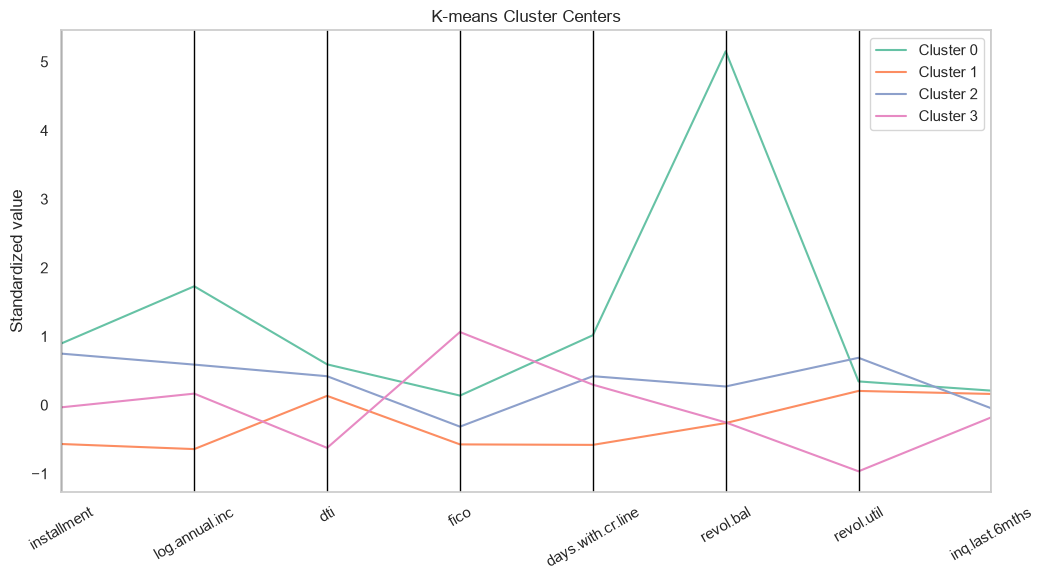

In [25]:
# Prompt: Recreate the K-means parallel-coordinates chart for four loan
# clusters and the same eight standardized variables. Keep the plot close to
# the ordinary pandas/matplotlib output, with only a title and axis labels.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../../data/loanskpi.csv")
cluster_vars = [
    "installment", "log.annual.inc", "dti", "fico",
    "days.with.cr.line", "revol.bal", "revol.util", "inq.last.6mths",
]
scaled_values = StandardScaler().fit_transform(df[cluster_vars])
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_values)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_vars)
centers["cluster"] = [f"Cluster {i}" for i in range(len(centers))]

plt.figure(figsize=(12, 6))
parallel_coordinates(centers, "cluster", color=sns.color_palette("Set2", 4))
plt.title("K-means Cluster Centers")
plt.ylabel("Standardized value")
plt.xticks(rotation=30)
plt.show()